# Dataset Load and Initial Inspection

In [1]:
import pandas as pd
data =pd.read_csv("data_clean.csv")
data

,Unnamed: 0,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,1,41.0,190.0,7.4,67,5,1,2010,67,S
1,2,36.0,118.0,8.0,72,5,2,2010,72,C
2,3,12.0,149.0,12.6,74,5,3,2010,74,PS
3,4,18.0,313.0,11.5,62,5,4,2010,62,S
4,5,NaN,NaN,14.3,56,5,5,2010,56,S
...,...,...,...,...,...,...,...,...,...,...
153,154,41.0,190.0,7.4,67,5,1,2010,67,C
154,155,30.0,193.0,6.9,70,9,26,2010,70,PS
155,156,NaN,145.0,13.2,77,9,27,2010,77,S
156,157,14.0,191.0,14.3,75,9,28,2010,75,S


In [2]:
data_backup =data # Taking backup of originmal data

In [3]:
data.tail(10)

,Unnamed: 0,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
148,149,30.0,193.0,6.9,70,9,26,2010,70,C
149,150,NaN,145.0,13.2,77,9,27,2010,77,PS
150,151,14.0,191.0,14.3,75,9,28,2010,75,S
151,152,18.0,131.0,8.0,76,9,29,2010,76,PS
152,153,20.0,223.0,11.5,68,9,30,2010,68,S
153,154,41.0,190.0,7.4,67,5,1,2010,67,C
154,155,30.0,193.0,6.9,70,9,26,2010,70,PS
155,156,NaN,145.0,13.2,77,9,27,2010,77,S
156,157,14.0,191.0,14.3,75,9,28,2010,75,S
157,158,18.0,131.0,8.0,76,9,29,2010,76,C


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  158 non-null    int64  
 1   Ozone       120 non-null    float64
 2   Solar.R     151 non-null    float64
 3   Wind        158 non-null    float64
 4   Temp C      158 non-null    object 
 5   Month       158 non-null    object 
 6   Day         158 non-null    int64  
 7   Year        158 non-null    int64  
 8   Temp        158 non-null    int64  
 9   Weather     155 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 12.5+ KB


In [5]:
data.shape

(158, 10)

In [6]:
data.dtypes

Unnamed: 0      int64
Ozone         float64
Solar.R       float64
Wind          float64
Temp C         object
Month          object
Day             int64
Year            int64
Temp            int64
Weather        object
dtype: object

In [7]:
data.describe() # Basic Statistics

,Unnamed: 0,Ozone,Solar.R,Wind,Day,Year,Temp
count,158.000000,120.000000,151.000000,158.000000,158.000000,158.0,158.000000
mean,79.500000,41.583333,185.403974,9.957595,16.006329,2010.0,77.727848
std,45.754781,32.620709,88.723103,3.511261,8.997166,0.0,9.377877
min,1.000000,1.000000,7.000000,1.700000,1.000000,2010.0,56.000000
25%,40.250000,18.000000,119.000000,7.400000,8.000000,2010.0,72.000000
50%,79.500000,30.500000,197.000000,9.700000,16.000000,2010.0,78.500000
75%,118.750000,61.500000,257.000000,11.875000,24.000000,2010.0,84.000000
max,158.000000,168.000000,334.000000,20.700000,31.000000,2010.0,97.000000


## Datatype Conversions

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  158 non-null    int64  
 1   Ozone       120 non-null    float64
 2   Solar.R     151 non-null    float64
 3   Wind        158 non-null    float64
 4   Temp C      158 non-null    object 
 5   Month       158 non-null    object 
 6   Day         158 non-null    int64  
 7   Year        158 non-null    int64  
 8   Temp        158 non-null    int64  
 9   Weather     155 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 12.5+ KB


In [9]:
# This line shows an error
# data.Month = pd.to_numeric(data.Month)

In [10]:
#  The element at 23rd index is not integer it is object(String)
data .Month.head(25)

0       5
1       5
2       5
3       5
4       5
5       5
6       5
7       5
8       5
9       5
10      5
11      5
12      5
13      5
14      5
15      5
16      5
17      5
18      5
19      5
20      5
21      5
22      5
23    May
24      5
Name: Month, dtype: object

In [11]:
# So we have to replace May with 5
data.Month = data.Month.replace("May",5)
data.Month.head(25)

0     5
1     5
2     5
3     5
4     5
5     5
6     5
7     5
8     5
9     5
10    5
11    5
12    5
13    5
14    5
15    5
16    5
17    5
18    5
19    5
20    5
21    5
22    5
23    5
24    5
Name: Month, dtype: object

In [12]:
# Now do datatype coversion 
data.Month = pd.to_numeric(data.Month, errors="coerce") # errors="coerse" forces any nother value to convert like May to NA
data["Temp C"] = pd.to_numeric(data["Temp C"], errors="coerce")
data["Weather"] = data["Weather"].astype("category")

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Unnamed: 0  158 non-null    int64   
 1   Ozone       120 non-null    float64 
 2   Solar.R     151 non-null    float64 
 3   Wind        158 non-null    float64 
 4   Temp C      157 non-null    float64 
 5   Month       158 non-null    int64   
 6   Day         158 non-null    int64   
 7   Year        158 non-null    int64   
 8   Temp        158 non-null    int64   
 9   Weather     155 non-null    category
dtypes: category(1), float64(4), int64(5)
memory usage: 11.5 KB


## Duplicates

In [14]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
153    False
154    False
155    False
156    False
157    False
Length: 158, dtype: bool

In [15]:
# Count of duplicate rows
data[data.duplicated()].shape

(0, 10)

In [16]:
# Print the duplicated rows
data[data.duplicated()]

,Unnamed: 0,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather


In [17]:
# If duplicate records found, you drop the, by this
data =data.drop_duplicates()

In [18]:
data.shape

(158, 10)

## Drop unncessary columns

In [19]:
data.head()

,Unnamed: 0,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,1,41.0,190.0,7.4,67.0,5,1,2010,67,S
1,2,36.0,118.0,8.0,72.0,5,2,2010,72,C
2,3,12.0,149.0,12.6,74.0,5,3,2010,74,PS
3,4,18.0,313.0,11.5,62.0,5,4,2010,62,S
4,5,NaN,NaN,14.3,56.0,5,5,2010,56,S


In [20]:
# Taking backup one more time before removing removing anything
data_backup2 = data 

In [21]:
data = data.drop("Unnamed: 0",axis=1)
data.head()

,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,67.0,5,1,2010,67,S
1,36.0,118.0,8.0,72.0,5,2,2010,72,C
2,12.0,149.0,12.6,74.0,5,3,2010,74,PS
3,18.0,313.0,11.5,62.0,5,4,2010,62,S
4,NaN,NaN,14.3,56.0,5,5,2010,56,S


In [22]:
data = data.drop("Temp C",axis=1)
data.head()

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,NaN,NaN,14.3,5,5,2010,56,S


## Rename the columns

In [23]:
data = data.rename({"Solar.R":"Solar"}, axis=1)
data.head()

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,NaN,NaN,14.3,5,5,2010,56,S


## Finding all the missing values

In [24]:
cols = data.columns
cols

Index(['Ozone', 'Solar', 'Wind', 'Month', 'Day', 'Year', 'Temp', 'Weather'], dtype='object')

<Axes: >

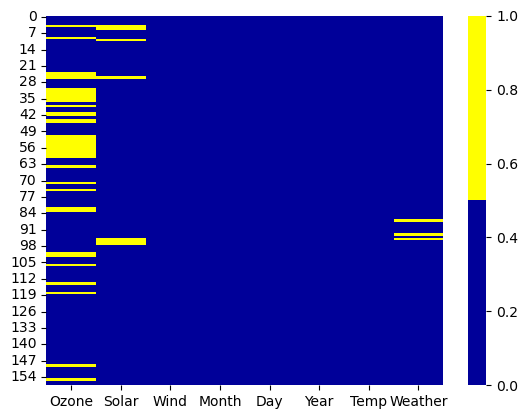

In [25]:
import seaborn  as sns
colours = ['#000099','#ffff00']
sns.heatmap(data[cols].isnull(),
           cmap = sns.color_palette(colours))

In [26]:
data.isnull().sum()

Ozone      38
Solar       7
Wind        0
Month       0
Day         0
Year        0
Temp        0
Weather     3
dtype: int64

## Handle missing values

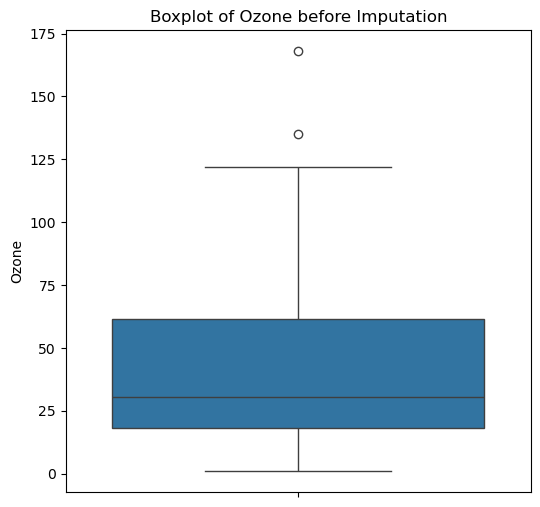

In [27]:
# Check wheather Ozone has outlier or not
import matplotlib.pyplot as plt

# Boxplot to check outlier
plt.figure(figsize=(6,6))
sns.boxplot(y=data.Ozone)
plt.title('Boxplot of Ozone before Imputation')
plt.show()

In [28]:
# There are outliers, Still we confirm with one Statistical method
# Calculate Q1 and Q2
Q1 = data.Ozone.quantile(0.25)
Q3 = data.Ozone.quantile(0.75)
IQR = Q3-Q1

# Define Outliers Bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find Outlier
outliers = data[(data.Ozone < lower_bound) | (data.Ozone > upper_bound)]
print("No. of outliers in Wind column are : ", outliers.shape[0])

No. of outliers in Wind column are :  2


In [29]:
# Hence as per stratgey, We will replace solar NA value with mean

In [30]:
# Fill with median
ozone_median = data.Ozone.median()
data.Ozone.fillna(ozone_median,inplace=True)
print("Filled with median:", ozone_median)

Filled with median: 30.5


C:\Users\asus\AppData\Local\Temp\ipykernel_15688\941207419.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Ozone.fillna(ozone_median,inplace=True)


In [31]:
# Check missing values in Ozone again
data.Ozone.isnull().sum()

np.int64(0)

In [32]:
# Now Boxplot to check outliers in Solar column
data.head()

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,30.5,NaN,14.3,5,5,2010,56,S


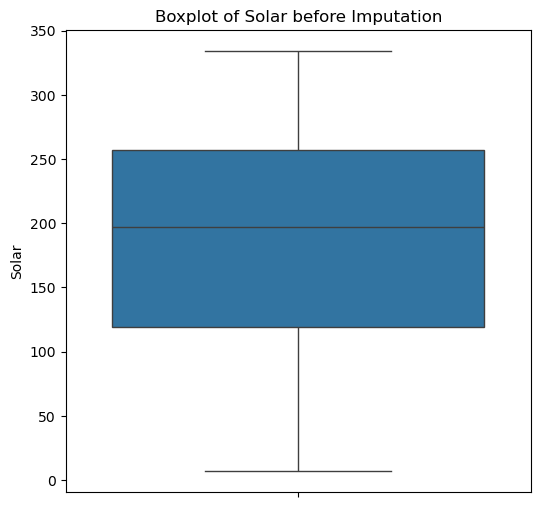

In [33]:
# Boxplot to check outlier
plt.figure(figsize=(6,6))
sns.boxplot(y=data.Solar)
plt.title('Boxplot of Solar before Imputation')
plt.show()

In [34]:
# There are outliers, Still we confirm with one Statistical method
# Calculate Q1 and Q2
Q1 = data.Solar.quantile(0.25)
Q3 = data.Solar.quantile(0.75)
IQR = Q3-Q1

# Define Outliers Bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find Outlier
outliers = data[(data.Solar < lower_bound) | (data.Solar > upper_bound)]
print("No. of outliers in Solar column are : ", outliers.shape[0])

No. of outliers in Solar column are :  0


In [35]:
# Fill with mean
solar_mean = data.Solar.mean()
data.Solar.fillna(solar_mean,inplace=True)
print("Filled with mean:", solar_mean)

Filled with mean: 185.40397350993376


C:\Users\asus\AppData\Local\Temp\ipykernel_15688\634465787.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Solar.fillna(solar_mean,inplace=True)


In [36]:
# Check missing values in Solar again
data.Solar.isnull().sum()

np.int64(0)

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   Ozone    158 non-null    float64 
 1   Solar    158 non-null    float64 
 2   Wind     158 non-null    float64 
 3   Month    158 non-null    int64   
 4   Day      158 non-null    int64   
 5   Year     158 non-null    int64   
 6   Temp     158 non-null    int64   
 7   Weather  155 non-null    category
dtypes: category(1), float64(3), int64(4)
memory usage: 9.1 KB


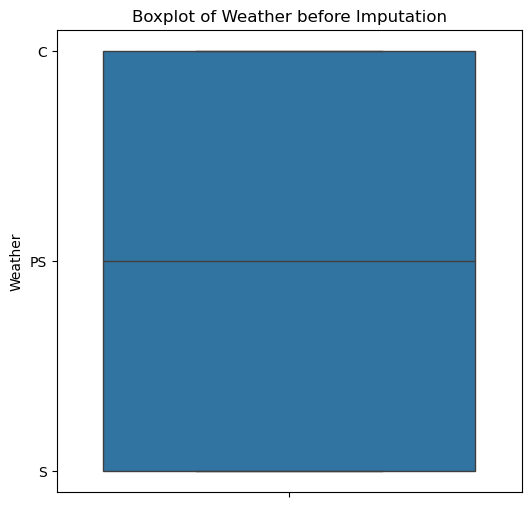

In [38]:
# Boxplot to check outlier
plt.figure(figsize=(6,6))
sns.boxplot(y=data.Weather)
plt.title('Boxplot of Weather before Imputation')
plt.show()

In [39]:
# Check missing values in Weather
data.Weather.isnull().sum()

np.int64(3)

In [40]:
# Checking most frequent value (mode)
weather_mode = data.Weather.mode()[0]
weather_mode

'S'

In [41]:
# Filling with mode value
data.Weather.fillna(weather_mode,inplace=True)

C:\Users\asus\AppData\Local\Temp\ipykernel_15688\2401830294.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Weather.fillna(weather_mode,inplace=True)


In [42]:
# Check missing values in Solar again
data.Weather.isnull().sum()

np.int64(0)

In [43]:
# Now check whole data does any column contains NA or not
data.isnull().sum()

Ozone      0
Solar      0
Wind       0
Month      0
Day        0
Year       0
Temp       0
Weather    0
dtype: int64

## How to dectect Outliers

<Axes: >

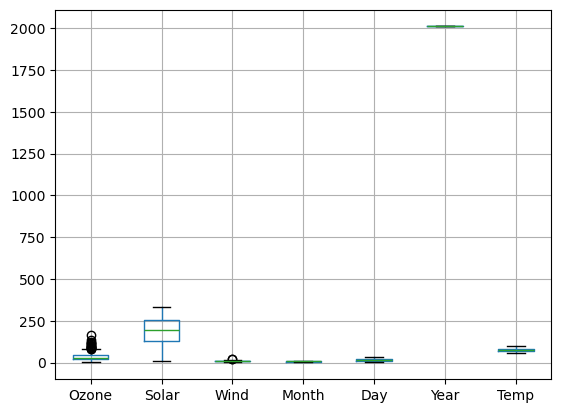

In [44]:
data.boxplot()

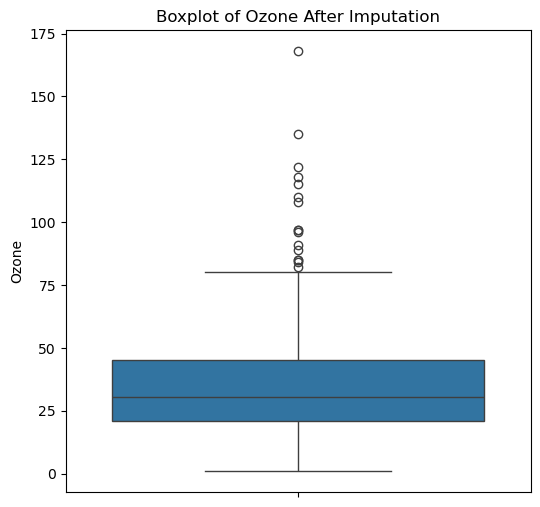

In [45]:
# Boxplot to check outlier
plt.figure(figsize=(6,6))
sns.boxplot(y=data.Ozone)
plt.title('Boxplot of Ozone After Imputation')
plt.show()

In [46]:
# There are outliers, Still we confirm with one Statistical method
# Calculate Q1 and Q2
Q1 = data.Ozone.quantile(0.25)
Q3 = data.Ozone.quantile(0.75)
IQR = Q3-Q1

# Define Outliers Bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find Outlier
outliers = data[(data.Ozone < lower_bound) | (data.Ozone > upper_bound)]
print("No. of outliers in Wind column are : ", outliers.shape[0])

No. of outliers in Wind column are :  16


In [47]:
median_value1 = data.Ozone.median()
print(median_value1)

30.5


In [48]:
# Replace Outliers with median
data.loc[data.Ozone < lower_bound, 'Ozone'] = median_value1
data.loc[data.Ozone > upper_bound, 'Ozone'] = median_value1

In [49]:
outliers1 = data[(data.Ozone < lower_bound) | (data.Ozone > upper_bound)]
print("No. of outliers in Wind column are : ", outliers1.shape[0])

No. of outliers in Wind column are :  0


# Scatter and Correlational Analysis

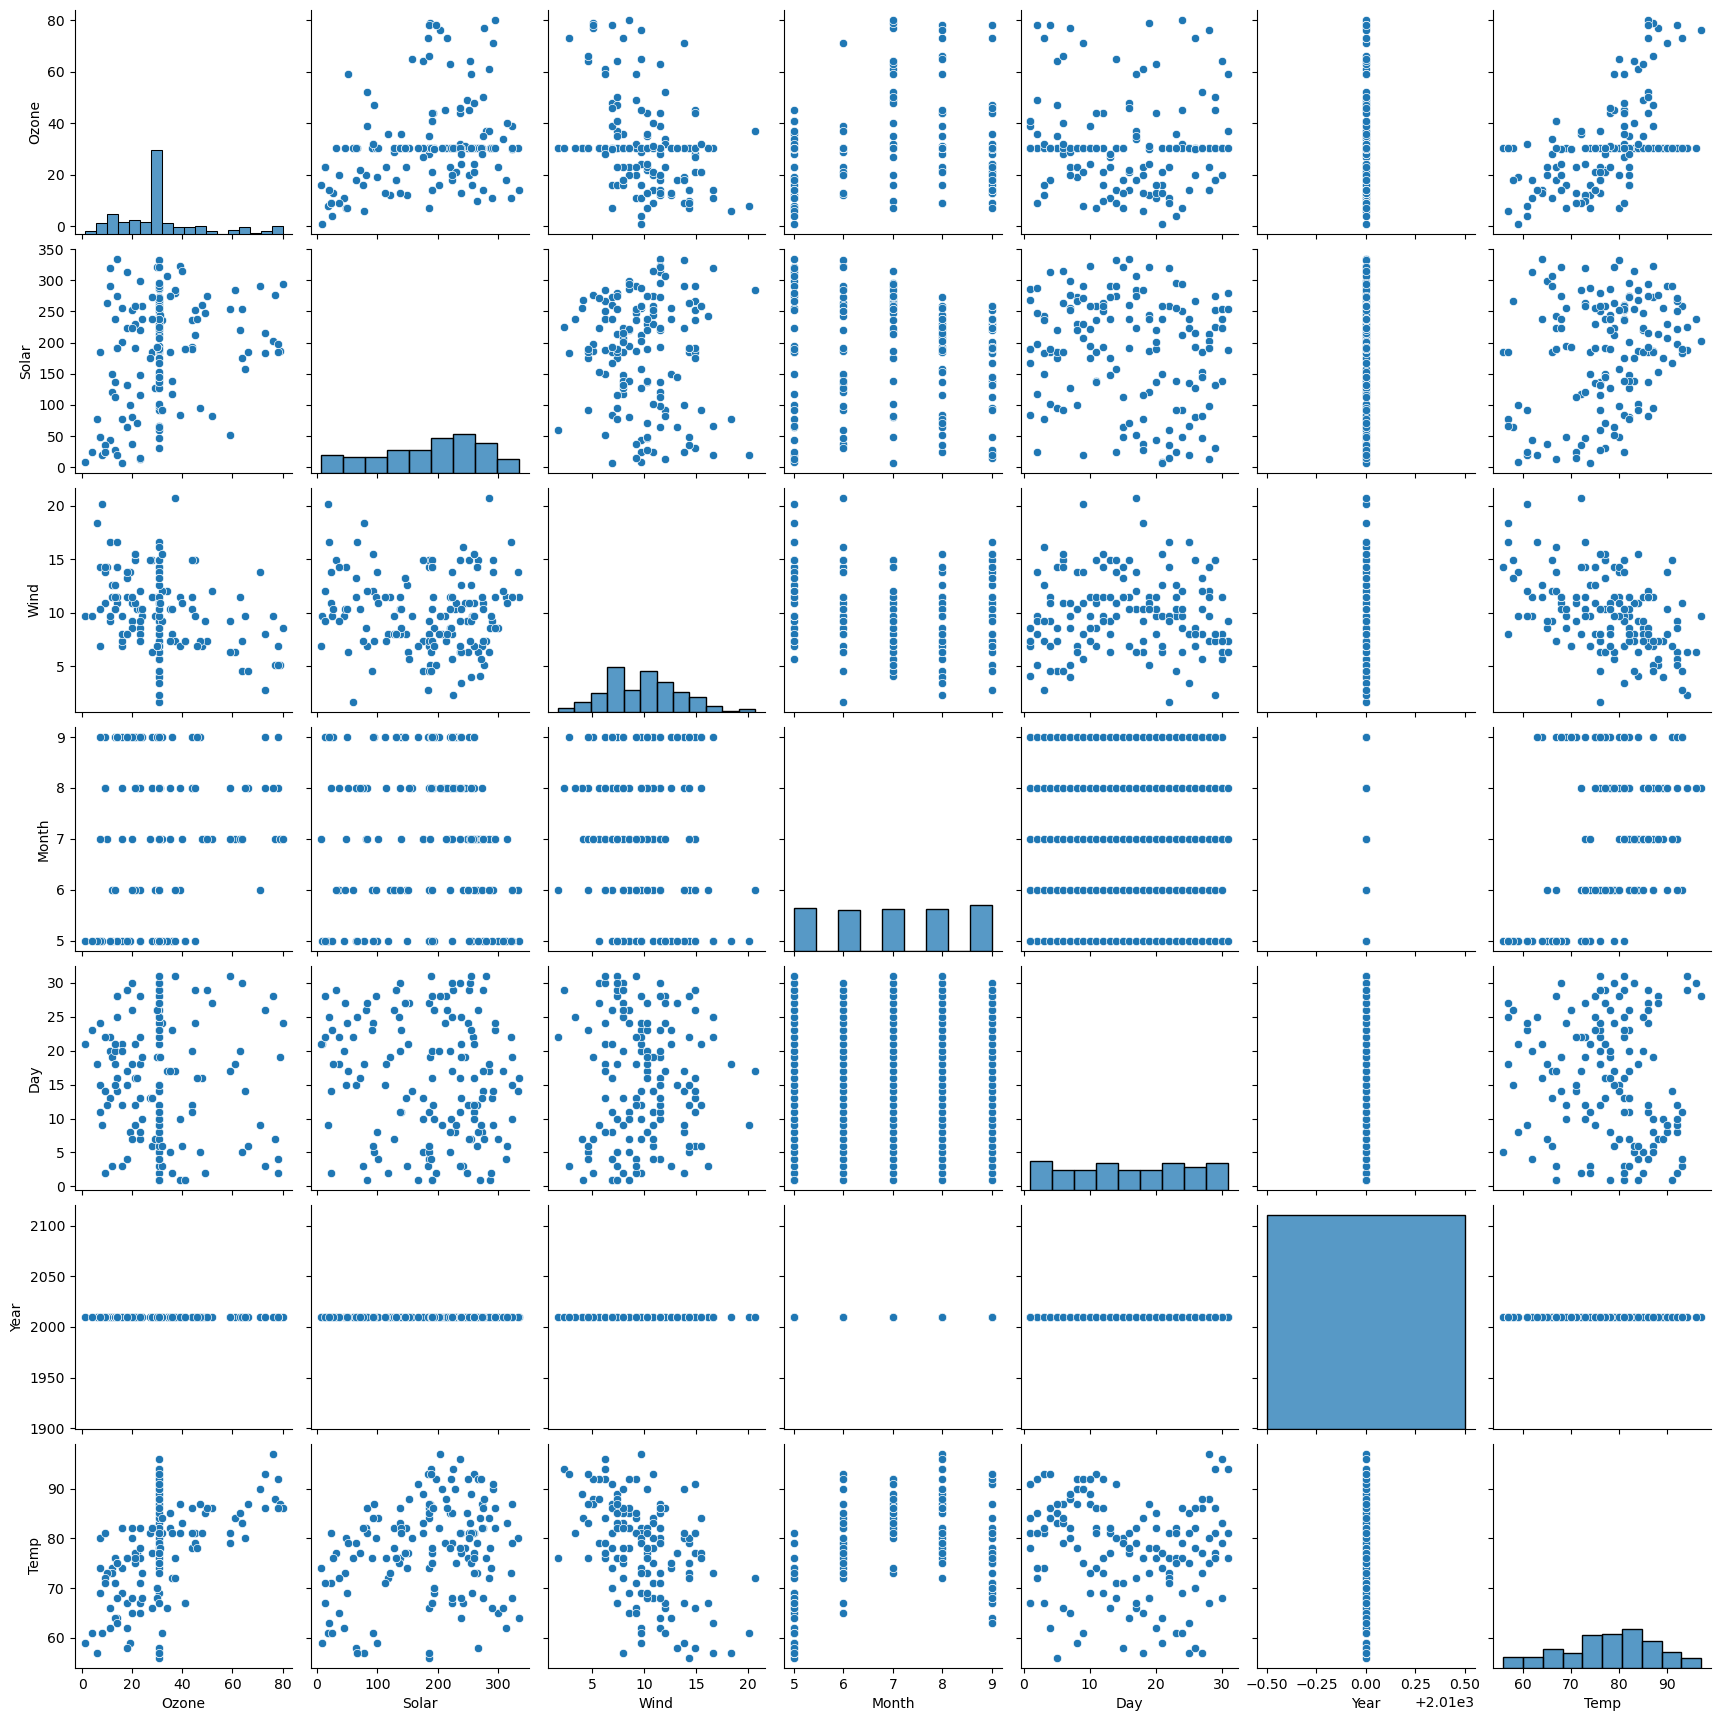

In [50]:
sns.pairplot(data)

In [51]:
# Correlaton
data.corr(numeric_only=True)

,Ozone,Solar,Wind,Month,Day,Year,Temp
Ozone,1.000000,0.288578,-0.352902,0.120973,-0.066719,NaN,0.511967
Solar,0.288578,1.000000,-0.055092,-0.079196,-0.149606,NaN,0.260473
Wind,-0.352902,-0.055092,1.000000,-0.157623,0.040151,NaN,-0.441247
Month,0.120973,-0.079196,-0.157623,1.000000,0.052646,NaN,0.402942
Day,-0.066719,-0.149606,0.040151,0.052646,1.000000,NaN,-0.124538
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temp,0.511967,0.260473,-0.441247,0.402942,-0.124538,NaN,1.000000


# Dummy Variables

In [56]:
#  Creating dummy variable for Weather  column
# data= pd.get_dummies(data,columns=['Weather']) # This give result in True False
# data

In [55]:
# This give result in 1 & 0 
data= pd.get_dummies(data,columns=['Weather']).astype(int)
data

,Ozone,Solar,Wind,Month,Day,Year,Temp,Weather_C,Weather_PS,Weather_S
0,41,190,7,5,1,2010,67,0,0,1
1,36,118,8,5,2,2010,72,1,0,0
2,12,149,12,5,3,2010,74,0,1,0
3,18,313,11,5,4,2010,62,0,0,1
4,30,185,14,5,5,2010,56,0,0,1
...,...,...,...,...,...,...,...,...,...,...
153,41,190,7,5,1,2010,67,1,0,0
154,30,193,6,9,26,2010,70,0,1,0
155,30,145,13,9,27,2010,77,0,0,1
156,14,191,14,9,28,2010,75,0,0,1


# Normalization of data

In [57]:
from numpy import set_printoptions
from sklearn.preprocessing import MinMaxScaler

In [60]:
data.values

array([[ 41, 190,   7, ...,   0,   0,   1],
       [ 36, 118,   8, ...,   1,   0,   0],
       [ 12, 149,  12, ...,   0,   1,   0],
       ...,
       [ 30, 145,  13, ...,   0,   0,   1],
       [ 14, 191,  14, ...,   0,   0,   1],
       [ 18, 131,   8, ...,   1,   0,   0]], shape=(158, 10))

In [61]:
array =data.values
array

array([[ 41, 190,   7, ...,   0,   0,   1],
       [ 36, 118,   8, ...,   1,   0,   0],
       [ 12, 149,  12, ...,   0,   1,   0],
       ...,
       [ 30, 145,  13, ...,   0,   0,   1],
       [ 14, 191,  14, ...,   0,   0,   1],
       [ 18, 131,   8, ...,   1,   0,   0]], shape=(158, 10))

In [62]:
scaler = MinMaxScaler(feature_range=(0,1))
rescaledX = scaler.fit_transform(array)

In [64]:
# Transformed data
set_printoptions(precision=2)
print(rescaledX[0:5,:])

[[0.51 0.56 0.32 0.   0.   0.   0.27 0.   0.   1.  ]
 [0.44 0.34 0.37 0.   0.03 0.   0.39 1.   0.   0.  ]
 [0.14 0.43 0.58 0.   0.07 0.   0.44 0.   1.   0.  ]
 [0.22 0.94 0.53 0.   0.1  0.   0.15 0.   0.   1.  ]
 [0.37 0.54 0.68 0.   0.13 0.   0.   0.   0.   1.  ]]


In [65]:
# Standardize data (0 mean , 1 stdev)
from sklearn.preprocessing import StandardScaler

In [66]:
array =data.values
scaler =StandardScaler()
scaler.fit(array)
rescaledX = scaler.transform(array)

# Summarize transform data
set_printoptions(precision=2)
print(rescaledX[0:5,:])

[[ 0.59  0.05 -0.71 -1.42 -1.67  0.   -1.15 -0.67 -0.65  1.24]
 [ 0.29 -0.78 -0.43 -1.42 -1.56  0.   -0.61  1.49 -0.65 -0.8 ]
 [-1.15 -0.42  0.73 -1.42 -1.45  0.   -0.4  -0.67  1.54 -0.8 ]
 [-0.79  1.48  0.44 -1.42 -1.34  0.   -1.68 -0.67 -0.65  1.24]
 [-0.07 -0.    1.3  -1.42 -1.23  0.   -2.32 -0.67 -0.65  1.24]]
